# Text Analysis EDA - Top 20 Labels from Textual Data

This notebook analyzes the textual data from train.csv to extract:
- Top 20 most frequent words/terms
- Top 20 most important TF-IDF terms
- Top 20 terms most correlated with price
- Word clouds and frequency distributions

In [1]:
# Import libraries for text analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import SelectKBest, f_regression
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
# Load and prepare text data
train_df = pd.read_csv('../dataset/train.csv')
print(f"Dataset shape: {train_df.shape}")
print(f"Columns: {train_df.columns.tolist()}")

# Extract all text from catalog_content
def extract_all_text(content):
    """Extract and clean all text from catalog content"""
    if not isinstance(content, str):
        return ''
    
    # Remove structured labels and keep only the content
    text = content.replace('Item Name:', '')
    text = re.sub(r'Bullet Point \d+:', '', text)
    text = text.replace('Value:', '').replace('Unit:', '')
    
    # Clean the text
    text = re.sub(r'[^\w\s]', ' ', text)  # Remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'\s+', ' ', text)  # Remove extra spaces
    text = text.lower().strip()
    
    return text

train_df['clean_text'] = train_df['catalog_content'].apply(extract_all_text)

# Remove empty text entries
text_mask = train_df['clean_text'].str.len() > 10
train_df_text = train_df[text_mask].copy()

print(f"Samples with meaningful text: {len(train_df_text)}")
print(f"Sample cleaned text:")
for i in range(3):
    print(f"{i+1}. {train_df_text['clean_text'].iloc[i][:100]}...")

Dataset shape: (75000, 4)
Columns: ['sample_id', 'catalog_content', 'image_link', 'price']
Samples with meaningful text: 74994
Sample cleaned text:
1. la victoria green taco sauce mild ounce pack of fl oz...
2. salerno cookies the original butter cookies ounce pack of original butter cookies classic butter coo...
3. bear creek hearty soup bowl creamy chicken with rice ounce pack of loaded with hearty long grain wil...


1. TOP 20 MOST FREQUENT WORDS
Top 20 Most Frequent Words:
 1. flavor          (80,277 occurrences)
 2. tea             (74,830 occurrences)
 3. ounce           (68,535 occurrences)
 4. product         (63,360 occurrences)
 5. free            (62,232 occurrences)
 6. pack            (49,599 occurrences)
 7. coffee          (44,371 occurrences)
 8. taste           (41,125 occurrences)
 9. natural         (38,757 occurrences)
10. ingredient      (36,726 occurrences)
11. organic         (36,265 occurrences)
12. snack           (33,779 occurrences)
13. bag             (33,189 occurrences)
14. perfect         (33,160 occurrences)
15. description     (32,989 occurrences)
16. made            (32,097 occurrences)
17. quality         (30,930 occurrences)
18. candy           (30,403 occurrences)
19. sugar           (30,069 occurrences)
20. water           (29,017 occurrences)


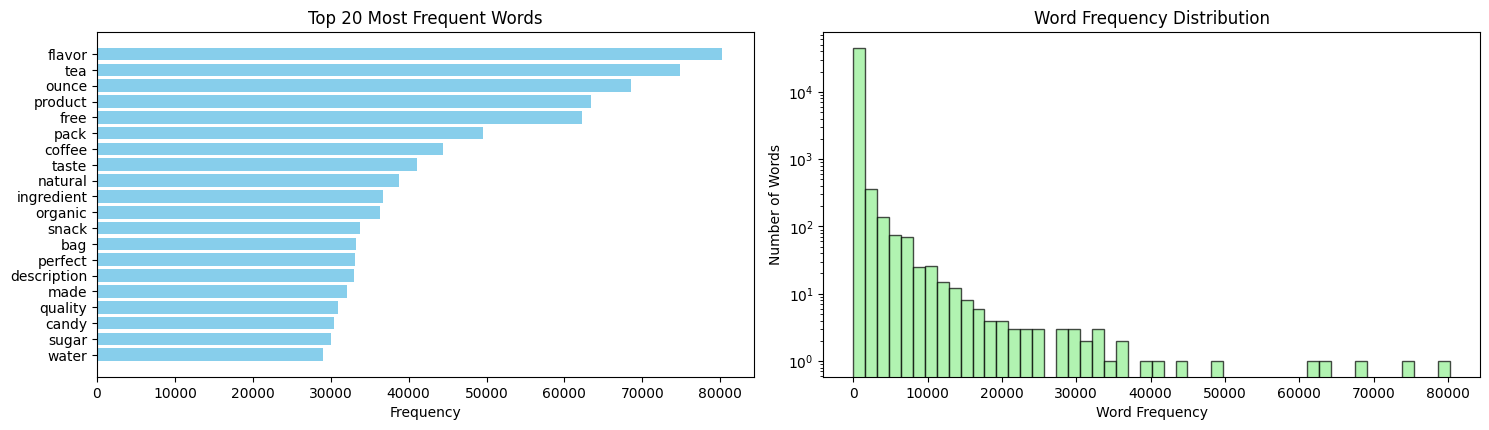

In [8]:
# 1. TOP 20 MOST FREQUENT WORDS
print("=" * 60)
print("1. TOP 20 MOST FREQUENT WORDS")
print("=" * 60)

# Tokenize and count words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

all_words = []
for text in train_df_text['clean_text']:
    tokens = word_tokenize(text)
    # Filter out stop words and short words
    filtered_tokens = [
        lemmatizer.lemmatize(word) for word in tokens 
        if word not in stop_words and len(word) > 2
    ]
    all_words.extend(filtered_tokens)

# Count word frequencies
word_freq = Counter(all_words)
top_20_words = word_freq.most_common(20)

print("Top 20 Most Frequent Words:")
for i, (word, count) in enumerate(top_20_words, 1):
    print(f"{i:2d}. {word:<15} ({count:,} occurrences)")

# Visualize word frequencies
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
words, counts = zip(*top_20_words)
plt.barh(range(len(words)), counts, color='skyblue')
plt.yticks(range(len(words)), words)
plt.xlabel('Frequency')
plt.title('Top 20 Most Frequent Words')
plt.gca().invert_yaxis()

# Word frequency distribution
plt.subplot(2, 2, 2)
all_counts = list(word_freq.values())
plt.hist(all_counts, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
plt.xlabel('Word Frequency')
plt.ylabel('Number of Words')
plt.title('Word Frequency Distribution')
plt.yscale('log')

plt.tight_layout()
plt.show()

2. TOP 20 HIGHEST TF-IDF SCORING TERMS
Top 20 TF-IDF Terms:
 1. oz                   (TF-IDF: 0.0540)
 2. ounce                (TF-IDF: 0.0522)
 3. tea                  (TF-IDF: 0.0398)
 4. pack                 (TF-IDF: 0.0395)
 5. free                 (TF-IDF: 0.0363)
 6. count                (TF-IDF: 0.0343)
 7. coffee               (TF-IDF: 0.0311)
 8. organic              (TF-IDF: 0.0306)
 9. product              (TF-IDF: 0.0287)
10. fl                   (TF-IDF: 0.0276)
11. fl oz                (TF-IDF: 0.0276)
12. flavor               (TF-IDF: 0.0268)
13. chocolate            (TF-IDF: 0.0243)
14. description          (TF-IDF: 0.0224)
15. product description  (TF-IDF: 0.0222)
16. candy                (TF-IDF: 0.0222)
17. natural              (TF-IDF: 0.0212)
18. gluten               (TF-IDF: 0.0207)
19. sugar                (TF-IDF: 0.0205)
20. mix                  (TF-IDF: 0.0197)


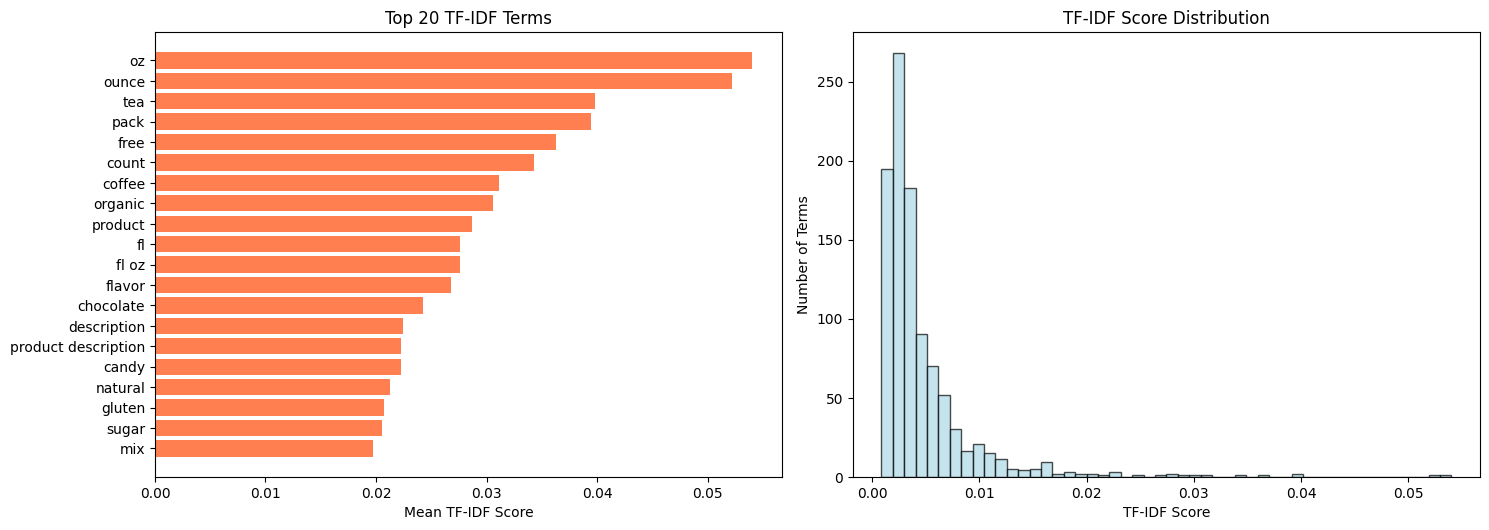

In [4]:
# 2. TOP 20 TF-IDF TERMS
print("=" * 60)
print("2. TOP 20 HIGHEST TF-IDF SCORING TERMS")
print("=" * 60)

# TF-IDF analysis
tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    min_df=5,  # Word must appear in at least 5 documents
    max_df=0.95,  # Word must appear in less than 95% of documents
    ngram_range=(1, 2)  # Include unigrams and bigrams
)

tfidf_matrix = tfidf.fit_transform(train_df_text['clean_text'])
feature_names = tfidf.get_feature_names_out()

# Calculate mean TF-IDF scores
mean_tfidf_scores = np.mean(tfidf_matrix.toarray(), axis=0)
tfidf_scores = list(zip(feature_names, mean_tfidf_scores))
tfidf_scores.sort(key=lambda x: x[1], reverse=True)

top_20_tfidf = tfidf_scores[:20]

print("Top 20 TF-IDF Terms:")
for i, (term, score) in enumerate(top_20_tfidf, 1):
    print(f"{i:2d}. {term:<20} (TF-IDF: {score:.4f})")

# Visualize TF-IDF scores
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
terms, scores = zip(*top_20_tfidf)
plt.barh(range(len(terms)), scores, color='coral')
plt.yticks(range(len(terms)), terms)
plt.xlabel('Mean TF-IDF Score')
plt.title('Top 20 TF-IDF Terms')
plt.gca().invert_yaxis()

# TF-IDF score distribution
plt.subplot(2, 2, 2)
plt.hist(mean_tfidf_scores, bins=50, alpha=0.7, color='lightblue', edgecolor='black')
plt.xlabel('TF-IDF Score')
plt.ylabel('Number of Terms')
plt.title('TF-IDF Score Distribution')

plt.tight_layout()
plt.show()

3. TOP 20 TERMS MOST CORRELATED WITH PRICE
Top 20 Terms Most Correlated with Price:
 1. zin pack             (F-score: 3425.60)
 2. case                 (F-score: 3294.88)
 3. fillers manufacturer (F-score: 2612.21)
 4. terravita size       (F-score: 2612.21)
 5. terravita            (F-score: 2412.78)
 6. convenient upright   (F-score: 2257.04)
 7. upright pouch        (F-score: 2257.04)
 8. manufacturer terravita (F-score: 2255.57)
 9. pouch product        (F-score: 2243.00)
10. upright              (F-score: 2087.60)
11. packed convenient    (F-score: 2020.69)
12. zin                  (F-score: 1920.57)
13. cups freshly         (F-score: 1907.13)
14. serving pitcher      (F-score: 1903.65)
15. drawn                (F-score: 1902.08)
16. pitcher pour         (F-score: 1897.95)
17. tea brewing          (F-score: 1896.40)
18. water pot            (F-score: 1892.40)
19. resistant pitcher    (F-score: 1888.99)
20. teapot pour          (F-score: 1885.19)

Price analysis for top 5 terms:



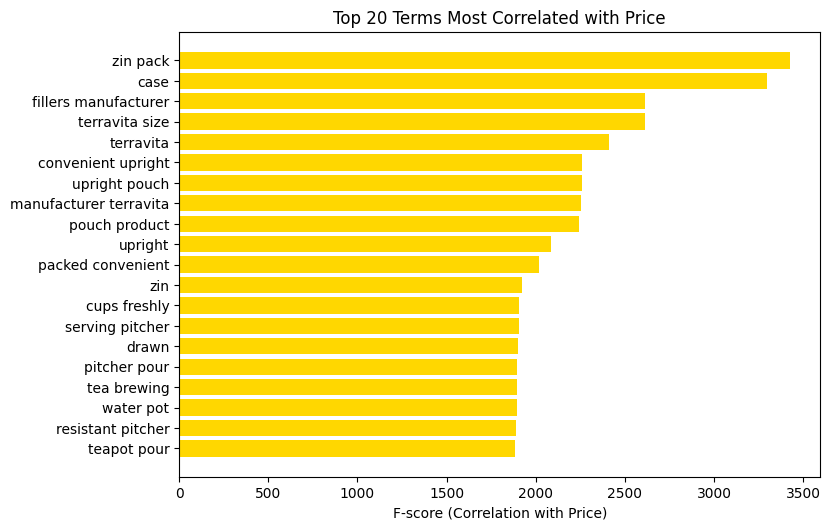

In [5]:
# 3. TOP 20 TERMS MOST CORRELATED WITH PRICE
print("=" * 60)
print("3. TOP 20 TERMS MOST CORRELATED WITH PRICE")
print("=" * 60)

# Use SelectKBest to find terms most correlated with price
selector = SelectKBest(score_func=f_regression, k=20)
X_selected = selector.fit_transform(tfidf_matrix, train_df_text['price'])
selected_indices = selector.get_support(indices=True)
selected_features = feature_names[selected_indices]
feature_scores = selector.scores_[selected_indices]

# Create list of top terms by correlation with price
price_correlated_terms = list(zip(selected_features, feature_scores))
price_correlated_terms.sort(key=lambda x: x[1], reverse=True)

print("Top 20 Terms Most Correlated with Price:")
for i, (term, score) in enumerate(price_correlated_terms, 1):
    print(f"{i:2d}. {term:<20} (F-score: {score:.2f})")

# Analyze price ranges for top terms
print("\nPrice analysis for top 5 terms:")
for term, _ in price_correlated_terms[:5]:
    term_idx = list(feature_names).index(term)
    # Find documents containing this term
    term_docs = tfidf_matrix[:, term_idx].toarray().flatten() > 0
    prices_with_term = train_df_text[term_docs]['price']
    prices_without_term = train_df_text[~term_docs]['price']
    
    print(f"\n{term}:")
    print(f"  With term: {len(prices_with_term)} docs, avg price: ${prices_with_term.mean():.2f}")
    print(f"  Without term: {len(prices_without_term)} docs, avg price: ${prices_without_term.mean():.2f}")
    print(f"  Price difference: ${prices_with_term.mean() - prices_without_term.mean():.2f}")

# Visualize price correlation
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
terms, scores = zip(*price_correlated_terms)
plt.barh(range(len(terms)), scores, color='gold')
plt.yticks(range(len(terms)), terms)
plt.xlabel('F-score (Correlation with Price)')
plt.title('Top 20 Terms Most Correlated with Price')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

4. TOP 20 PRODUCT CATEGORIES/TYPES
Top Product Categories:
 1. Food & Beverage      (53,264 products)
 2. Household            (20,528 products)
 3. Health & Beauty      (17,268 products)
 4. Other                (16,761 products)
 5. Electronics          (304 products)

Average price by category:
Food & Beverage     : $   24.25 (n=53264)
Household           : $   26.60 (n=20528)
Health & Beauty     : $   25.29 (n=17268)
Other               : $   21.50 (n=16761)
Electronics         : $   30.68 (n=304)


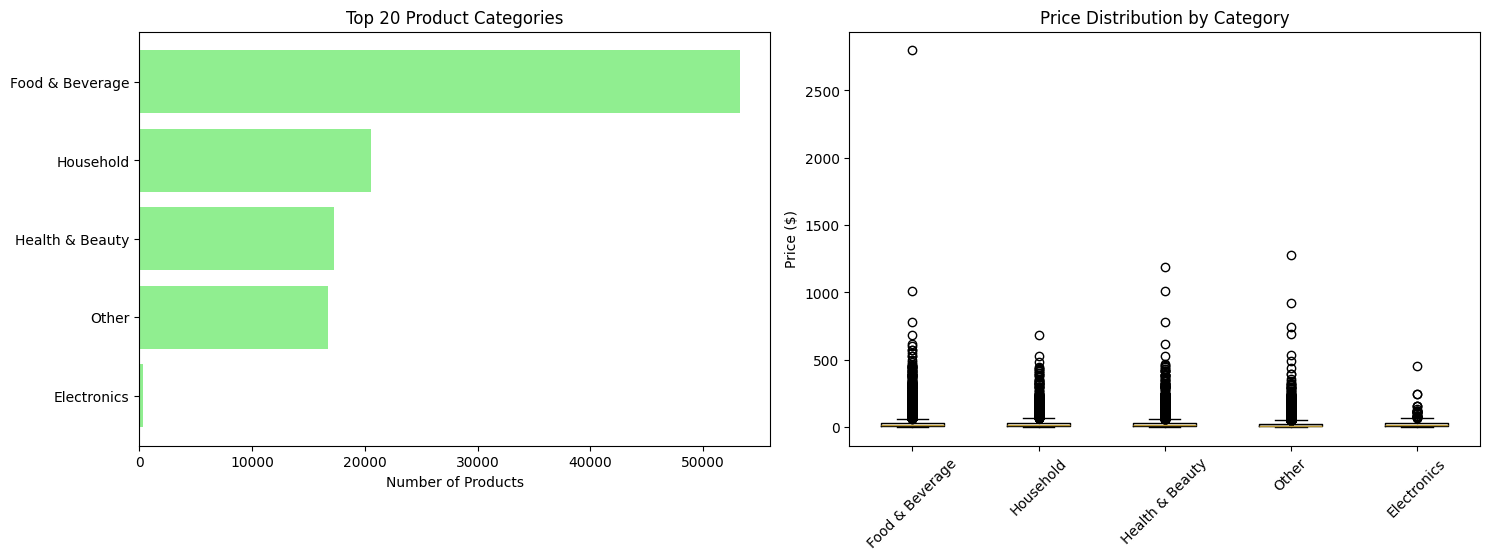

In [6]:
# 4. CATEGORY/PRODUCT TYPE ANALYSIS
print("=" * 60)
print("4. TOP 20 PRODUCT CATEGORIES/TYPES")
print("=" * 60)

# Extract product categories/types from item names
def extract_product_categories(text):
    """Extract likely product categories from text"""
    # Common product categories/types
    categories = []
    
    # Food related
    food_terms = ['sauce', 'soup', 'chips', 'crackers', 'cookies', 'candy', 'chocolate', 
                  'cereal', 'snack', 'drink', 'juice', 'coffee', 'tea', 'spice', 'oil']
    
    # Health/beauty
    health_terms = ['cream', 'lotion', 'shampoo', 'soap', 'vitamin', 'supplement', 
                    'medicine', 'care', 'beauty']
    
    # Household
    household_terms = ['cleaner', 'detergent', 'paper', 'towel', 'bag', 'container',
                       'kitchen', 'bathroom']
    
    # Electronics/tools
    tech_terms = ['battery', 'charger', 'cable', 'tool', 'device', 'electronic']
    
    all_categories = {
        'Food & Beverage': food_terms,
        'Health & Beauty': health_terms,
        'Household': household_terms,
        'Electronics': tech_terms
    }
    
    text_lower = text.lower()
    found_categories = []
    
    for category, terms in all_categories.items():
        if any(term in text_lower for term in terms):
            found_categories.append(category)
    
    return found_categories if found_categories else ['Other']

# Extract categories for each product
train_df_text['categories'] = train_df_text['clean_text'].apply(extract_product_categories)

# Count category frequencies
all_categories = []
for cat_list in train_df_text['categories']:
    all_categories.extend(cat_list)

category_counts = Counter(all_categories)
top_20_categories = category_counts.most_common(20)

print("Top Product Categories:")
for i, (category, count) in enumerate(top_20_categories, 1):
    print(f"{i:2d}. {category:<20} ({count:,} products)")

# Analyze price by category
print("\nAverage price by category:")
for category, _ in top_20_categories[:10]:
    category_mask = train_df_text['categories'].apply(lambda x: category in x)
    if category_mask.any():
        avg_price = train_df_text[category_mask]['price'].mean()
        count = category_mask.sum()
        print(f"{category:<20}: ${avg_price:>8.2f} (n={count})")

# Visualize categories
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
categories, counts = zip(*top_20_categories)
plt.barh(range(len(categories)), counts, color='lightgreen')
plt.yticks(range(len(categories)), categories)
plt.xlabel('Number of Products')
plt.title('Top 20 Product Categories')
plt.gca().invert_yaxis()

# Price distribution by top categories
plt.subplot(2, 2, 2)
top_categories = [cat for cat, _ in top_20_categories[:5]]
price_data = []
labels = []
for category in top_categories:
    category_mask = train_df_text['categories'].apply(lambda x: category in x)
    if category_mask.any():
        price_data.append(train_df_text[category_mask]['price'].values)
        labels.append(category)

plt.boxplot(price_data, labels=labels)
plt.title('Price Distribution by Category')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

5. TOP 20 BRANDS AND PRODUCT NAMES
Top 20 Potential Brands:
 1. organic         (5,916 mentions)
 2. tea             (5,185 mentions)
 3. chocolate       (2,820 mentions)
 4. coffee          (2,305 mentions)
 5. black           (1,848 mentions)
 6. original        (1,592 mentions)
 7. free            (1,506 mentions)
 8. candy           (1,482 mentions)
 9. food            (1,408 mentions)
10. white           (1,403 mentions)
11. sugar           (1,344 mentions)
12. red             (1,235 mentions)
13. green           (1,176 mentions)
14. fruit           (1,156 mentions)
15. whole           (1,143 mentions)
16. hot             (1,084 mentions)
17. gourmet         (1,083 mentions)
18. natural         (1,079 mentions)
19. foods           (1,073 mentions)
20. dark            (1,064 mentions)

Top 20 Product Descriptors:
 1. natural         (38,351 mentions)
 2. organic         (34,425 mentions)
 3. sweet           (22,209 mentions)
 4. premium         (17,368 mentions)
 5. fresh          

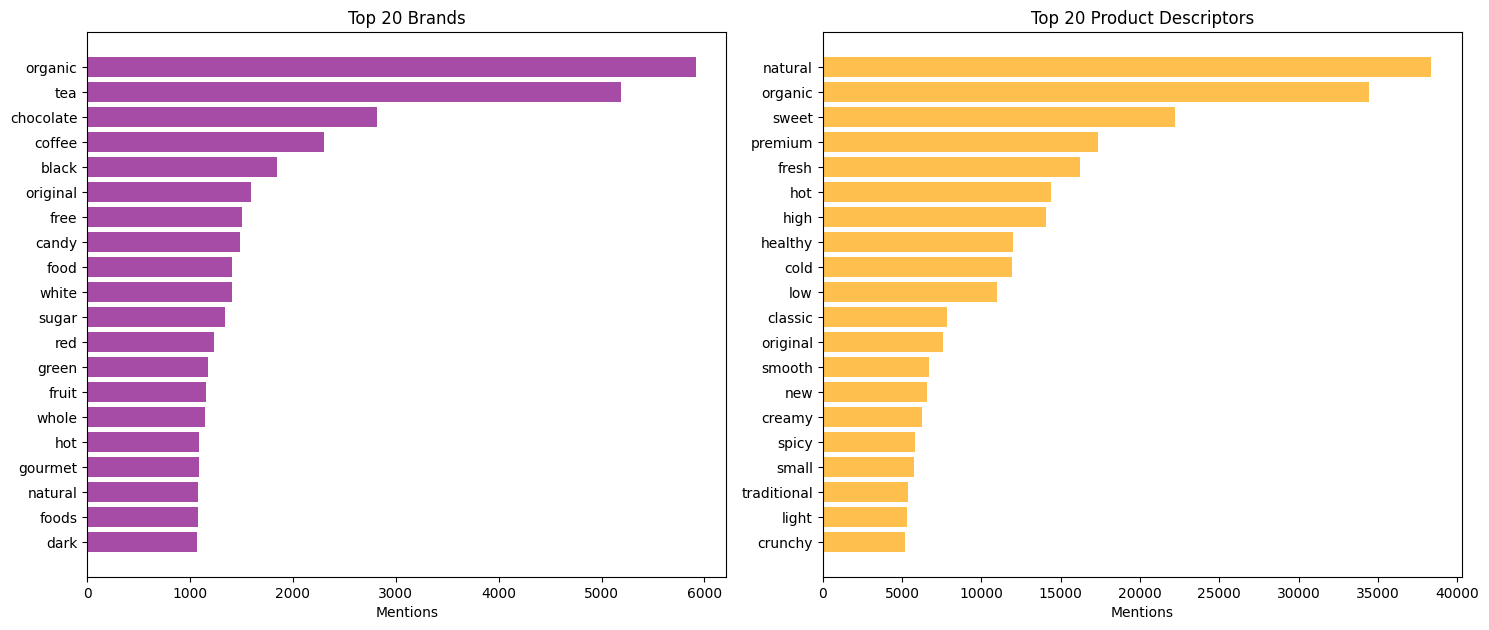

In [7]:
# 5. BRAND AND PRODUCT NAME ANALYSIS
print("=" * 60)
print("5. TOP 20 BRANDS AND PRODUCT NAMES")
print("=" * 60)

# Extract potential brand names (usually first word or capitalized words)
def extract_brands(text):
    """Extract potential brand names from text"""
    # Split text and look for capitalized words
    words = text.split()
    brands = []
    
    # Common brand indicators
    for word in words[:5]:  # Check first 5 words
        if word.istitle() and len(word) > 2:  # Capitalized and meaningful length
            brands.append(word.lower())
    
    return brands

# Extract brands
all_brands = []
for text in train_df_text['catalog_content'].astype(str):
    # Look specifically in item names
    item_match = re.search(r'Item Name: ([^\n]+)', text)
    if item_match:
        item_name = item_match.group(1)
        brands = extract_brands(item_name)
        all_brands.extend(brands)

brand_counts = Counter(all_brands)
top_20_brands = brand_counts.most_common(20)

print("Top 20 Potential Brands:")
for i, (brand, count) in enumerate(top_20_brands, 1):
    print(f"{i:2d}. {brand:<15} ({count:,} mentions)")

# Extract product descriptors (adjectives and key terms)
def extract_descriptors(text):
    """Extract descriptive terms from product text"""
    descriptors = []
    
    # Common product descriptors
    descriptor_patterns = [
        r'\b(organic|natural|premium|fresh|healthy|low|high|extra|super|mega|mini|large|small)\b',
        r'\b(creamy|crunchy|smooth|thick|thin|light|heavy|soft|hard)\b',
        r'\b(sweet|salty|spicy|hot|cold|warm|cool)\b',
        r'\b(new|original|classic|traditional|modern|vintage)\b'
    ]
    
    text_lower = text.lower()
    for pattern in descriptor_patterns:
        matches = re.findall(pattern, text_lower)
        descriptors.extend(matches)
    
    return descriptors

# Extract descriptors
all_descriptors = []
for text in train_df_text['clean_text']:
    descriptors = extract_descriptors(text)
    all_descriptors.extend(descriptors)

descriptor_counts = Counter(all_descriptors)
top_20_descriptors = descriptor_counts.most_common(20)

print("\nTop 20 Product Descriptors:")
for i, (descriptor, count) in enumerate(top_20_descriptors, 1):
    print(f"{i:2d}. {descriptor:<15} ({count:,} mentions)")

# Visualize brands and descriptors
plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
brands, brand_counts_vals = zip(*top_20_brands)
plt.barh(range(len(brands)), brand_counts_vals, color='purple', alpha=0.7)
plt.yticks(range(len(brands)), brands)
plt.xlabel('Mentions')
plt.title('Top 20 Brands')
plt.gca().invert_yaxis()

plt.subplot(2, 2, 2)
descriptors, desc_counts_vals = zip(*top_20_descriptors)
plt.barh(range(len(descriptors)), desc_counts_vals, color='orange', alpha=0.7)
plt.yticks(range(len(descriptors)), descriptors)
plt.xlabel('Mentions')
plt.title('Top 20 Product Descriptors')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()